In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import csv
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, classification_report, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MaxAbsScaler
from sklearn import tree
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
data = pd.read_csv('UNSW15_50.csv')
# datatest = pd.read_csv('UNSW15_test.csv')
print(data.shape)
#data = data.drop(['temp'], axis = 1)

(181997, 43)


In [ ]:
data.head(10)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.121478,1,0,1,6,4,258,172,74.087490,252,...,1,1,1,0,0,0,1,1,0,0
1,0.649902,1,0,1,14,38,734,42014,78.473372,62,...,1,1,2,0,0,0,1,6,0,0
2,1.623129,1,0,1,8,16,364,13186,14.170161,62,...,1,1,3,0,0,0,2,6,0,0
3,1.681642,1,1,1,12,12,628,770,13.677108,62,...,1,1,3,1,1,0,2,1,0,0
4,0.449454,1,0,1,10,6,534,268,33.373826,254,...,2,1,40,0,0,0,2,39,0,0
5,0.380537,1,0,1,10,6,534,268,39.417980,254,...,2,1,40,0,0,0,2,39,0,0
6,0.637109,1,0,1,10,8,534,354,26.683033,254,...,1,1,40,0,0,0,1,39,0,0
7,0.521584,1,0,1,10,8,534,354,32.593026,254,...,3,1,40,0,0,0,3,39,0,0
8,0.542905,1,0,1,10,8,534,354,31.313031,254,...,3,1,40,0,0,0,3,39,0,0
9,0.258687,1,0,1,10,6,534,268,57.985135,254,...,3,1,40,0,0,0,3,39,0,0


In [ ]:
missing_values = data.isnull().sum().sort_values(ascending = False)
missing_values

,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0
sttl,0


In [ ]:
print(data.columns)

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')


In [ ]:
encoder = LabelEncoder()
#data['proto'] = encoder.fit_transform(data['proto'])
#data['service'] = encoder.fit_transform(data['service'])

X = data.drop(['label',], axis=1)
y = data['label']
data.drop(['label',], axis = 1)

# X_test = datatest.drop(columns = ['label'], axis = 1)
# y_test = datatest['label']


# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)


#  Define hyperparameter grid
# param_grid = {
#     "max_depth":[3,5,10,None],
#     "min_samples_split":[2,5,10],
#     "min_samples_leaf":[1,2,5,10],
#     "criterion":["gini","entropy"],
# }


# dt = DecisionTreeClassifier(random_state=42)

# grid_search=GridSearchCV(dt,param_grid,cv=5,scoring="accuracy",n_jobs=-1)
# grid_search.fit(X_train,y_train)

# print("Best Parameters:",grid_search.best_params_)

dec = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state =42)
bagging_model = BaggingClassifier(dec, n_estimators=10, random_state=42)

bagging_model.fit(X_train, y_train)
dec.fit(X_train, y_train)

y_train_pred = dec.predict(X_train)
y_test_pred = dec.predict(X_test)

y_trainbag_pred = bagging_model.predict(X_train)
y_testbag_pred = bagging_model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
accuracy2 = accuracy_score(y_train, y_train_pred)
f1 = f1_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
precision = precision_score(y_test, y_test_pred, average='weighted')
print(f"Accuracy of train {accuracy2:.4f} ")
print(f"Accuracy of test: {accuracy:.4f}")
print(f"F1: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

accuracy_bag = accuracy_score(y_test, y_testbag_pred)
accuracy2_bag = accuracy_score(y_train, y_trainbag_pred)
f1_bag = f1_score(y_test, y_testbag_pred, average='weighted')
recall_bag = recall_score(y_test, y_testbag_pred, average='weighted')
precision_bag = precision_score(y_test, y_testbag_pred, average='weighted')
print(f"Bagging")
print(f"Accuracy of train {accuracy2_bag:.4f} ")
print(f"Accuracy of test: {accuracy_bag:.4f}")
print(f"F1: {f1_bag:.4f}")
print(f"Recall: {recall_bag:.4f}")
print(f"Precision: {precision_bag:.4f}")




Accuracy of train 0.7215 
Accuracy of test: 0.7080
F1: 0.7077
Recall: 0.7080
Precision: 0.7097
Bagging
Accuracy of train 0.7239 
Accuracy of test: 0.7113
F1: 0.7111
Recall: 0.7113
Precision: 0.7122


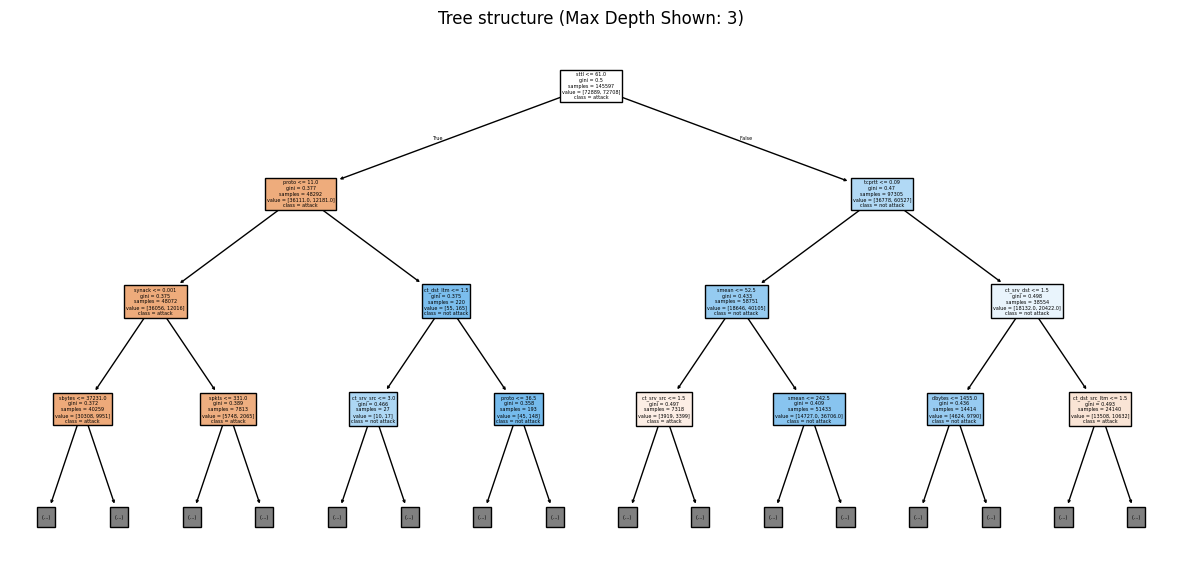

In [ ]:
plt.figure(figsize=(15, 7))
plot_tree(dec, feature_names=data.columns, class_names=["attack", "not attack"], filled=True, max_depth=3)
plt.title("Tree structure (Max Depth Shown: 3)")
plt.show()